In [26]:
import numpy as np
import matplotlib.pyplot as plt

file1 = '/raid1/genli/Data_D2O/runs_19520_19529_dt0-10000_sa0-50000_madc200_mcut2_std40.0/aggregated_sum_area.pkl'
file2 = '/raid1/genli/Data_D2O/runs_19520_19529_dt10000-20000_sa0-50000_madc200_mcut2_std40.0/aggregated_sum_area.pkl'

data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)

centers1 = data1['centers']
centers2 = data2['centers']
sum_area1 = data1['hist']
sum_area2 = data2['hist']
err1 = data1['errors']
err2 = data2['errors']

{'centers': array([ 1250.,  3750.,  6250.,  8750., 11250., 13750., 16250., 18750.,
       21250., 23750., 26250., 28750., 31250., 33750., 36250., 38750.,
       41250., 43750., 46250., 48750.]), 'hist': array([ 9706, 13501,  9959, 10417, 11014, 11326, 10959,  9186,  7179,
        5351,  4038,  3054,  2264,  1722,  1237,   973,   764,   617,
         521,   440]), 'errors': array([ 98.51903369, 116.19380362,  99.79478944, 102.0637056 ,
       104.94760598, 106.42368158, 104.68524251,  95.84362264,
        84.72897969,  73.15052973,  63.54525946,  55.26300752,
        47.58150901,  41.49698784,  35.17101079,  31.19294792,
        27.64054992,  24.8394847 ,  22.82542442,  20.97617696])}


[0.00896546 0.01032551 0.00722088 0.00668778 0.00591696 0.00600515
 0.0060878  0.00586144 0.00473136 0.00387979 0.00359125 0.00299471
 0.00294123 0.00250945 0.00223063 0.00184774 0.00126487 0.00103675
 0.00144743 0.00135349]


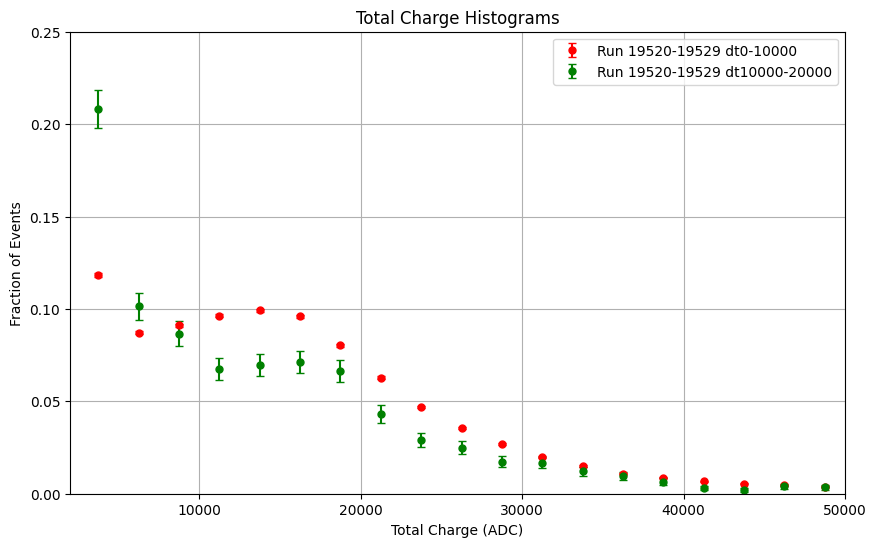

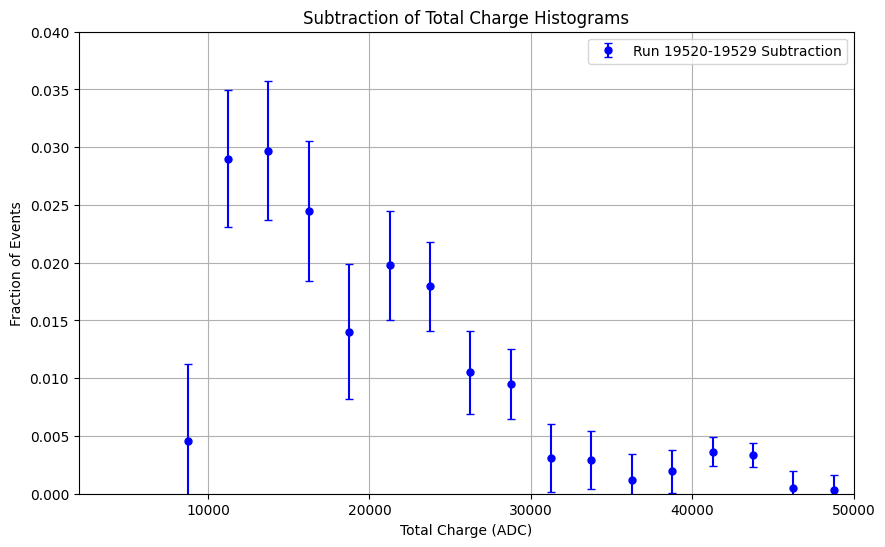

In [35]:
#Normalize the histograms and errors
# Convert to float to avoid casting errors
sum_area1 = sum_area1.astype(float)
sum_area2 = sum_area2.astype(float)
err1 = err1.astype(float)
err2 = err2.astype(float)

# Store original sums for proper error normalization
sum1_orig = np.sum(sum_area1)
sum2_orig = np.sum(sum_area2)

sum_area1 /= sum1_orig
sum_area2 /= sum2_orig
err1 /= sum1_orig  # Scale errors by the same factor as the histogram
err2 /= sum2_orig  # Scale errors by the same factor as the histogram
err_total = np.sqrt(err1**2 + err2**2)
print(err_total)

#plotting hist1 and hist2 on the same plot
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1, yerr=err1, fmt='o', label='Run 19520-19529 dt0-10000', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, sum_area2, yerr=err2, fmt='o', label='Run 19520-19529 dt10000-20000', color='green', markersize=5, capsize=3)
plt.title('Total Charge Histograms')
plt.xlabel('Total Charge (ADC)')
plt.ylabel('Fraction of Events')
plt.ylim(0, 0.25)
plt.xlim(2000, 50000)
plt.legend()
plt.grid()
# plt.savefig('total_charge_histograms.png')
plt.show()

#plotting subtraction hist1 - hist2
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1 - sum_area2, yerr=err_total, fmt='o', label='Run 19520-19529 Subtraction', color='blue', markersize=5, capsize=3)
plt.title('Subtraction of Total Charge Histograms')
plt.xlabel('Total Charge (ADC)')
plt.ylabel('Fraction of Events')
plt.ylim(0, 0.04)
plt.xlim(2000, 50000)
plt.legend()
plt.grid()
# plt.savefig('subtraction_histograms.png')
plt.show()